# Problem 1 [5 points] – IRIS/CLUSTERING
• IRIS is a “labelled” data. For now, we will ignore the class labels.
• Cluster the IRIS data into K = 2, 3, 4, 5 clusters
• Draw the Silhouette Score w.r.t. K

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
iris = load_iris()

X = iris.data

print("Dataset Shape :", X.shape)

Dataset Shape : (150, 4)


In [3]:
iris_df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
k_values = [2, 3, 4, 5]

silhouette_scores = []

In [6]:
for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}")
    print("Silhouette Score =", round(score,4))
    print("-"*40)

K = 2
Silhouette Score = 0.681
----------------------------------------
K = 3
Silhouette Score = 0.5528
----------------------------------------
K = 4
Silhouette Score = 0.4981
----------------------------------------
K = 5
Silhouette Score = 0.4887
----------------------------------------


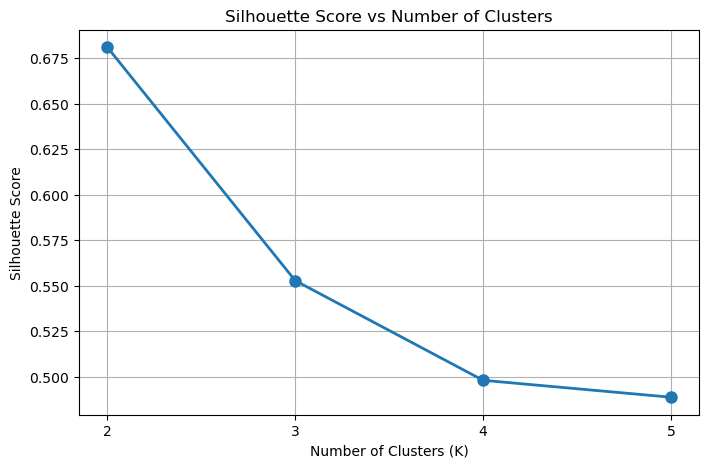

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(k_values)

plt.grid(True)

plt.show()

Conclusion:

1. K-Means clustering was performed on the Iris dataset for K = 2, 3, 4, and 5.
2. The Silhouette Score was computed for each value of K.
3. A higher Silhouette Score indicates better cluster separation.
4. In this experiment, K = 2 achieved the highest Silhouette Score, indicating the most compact and well-separated clusters among the tested values.
5. As K increased beyond 2, the Silhouette Score gradually decreased, suggesting reduced cluster quality.

# Problem 5 DIGITS/PCA-vs-Fisher
• Write a function that takes in any three classes of data
• Do a 2-D PCA on this data – plot the scatter plot – color code the three classes
• Do a 2-D Fisher on this data – plot the scatter plot – color code the three classes

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [9]:
digits = load_digits()

X = digits.data      # Features (64 pixels)
y = digits.target    # Labels (0-9)

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1797, 64)
Target Shape : (1797,)


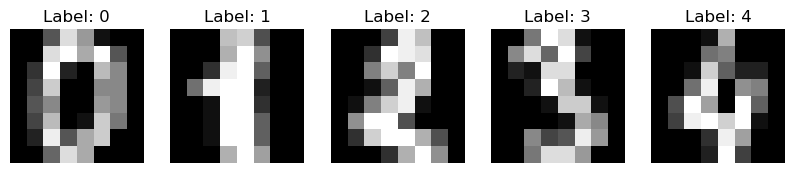

In [10]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")

plt.show()

In [11]:
def get_three_classes(class1, class2, class3):

    selected_classes = [class1, class2, class3]

    mask = np.isin(y, selected_classes)

    X_subset = X[mask]
    y_subset = y[mask]

    return X_subset, y_subset

In [12]:
X_subset, y_subset = get_three_classes(2,5,8)

print("Subset Shape :", X_subset.shape)

Subset Shape : (533, 64)


In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_subset)

print(X_pca.shape)

(533, 2)


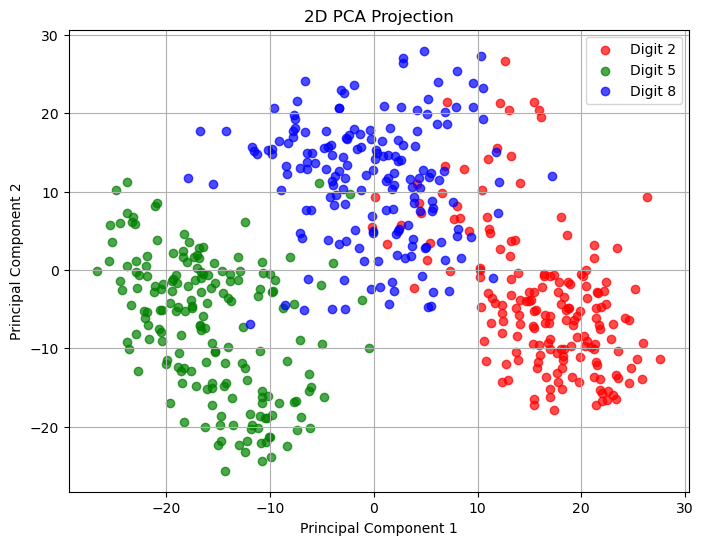

In [14]:
plt.figure(figsize=(8,6))

colors = ['red','green','blue']

for i, digit in enumerate(np.unique(y_subset)):

    plt.scatter(
        X_pca[y_subset==digit,0],
        X_pca[y_subset==digit,1],
        color=colors[i],
        label=f"Digit {digit}",
        alpha=0.7
    )

plt.title("2D PCA Projection")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [15]:
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_subset,
    y_subset
)

print(X_lda.shape)

(533, 2)


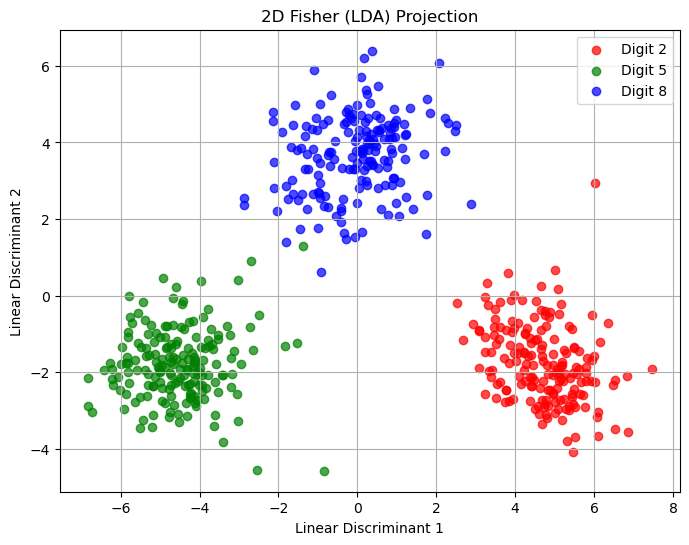

In [16]:
plt.figure(figsize=(8,6))

colors = ['red','green','blue']

for i, digit in enumerate(np.unique(y_subset)):

    plt.scatter(
        X_lda[y_subset==digit,0],
        X_lda[y_subset==digit,1],
        color=colors[i],
        label=f"Digit {digit}",
        alpha=0.7
    )

plt.title("2D Fisher (LDA) Projection")

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
def compare_pca_fisher(class1, class2, class3):
    # Get subset of data
    X_subset, y_subset = get_three_classes(class1, class2, class3)

    # PCA (unsupervised)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_subset)

    # LDA (supervised)
    n_classes = len(np.unique(y_subset))
    lda = LinearDiscriminantAnalysis(n_components=min(n_classes-1, 2))
    X_lda = lda.fit_transform(X_subset, y_subset)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = plt.cm.tab10(np.arange(n_classes))  # dynamic colormap
    labels = np.unique(y_subset)

    for i, label in enumerate(labels):
        axes[0].scatter(
            X_pca[y_subset == label, 0],
            X_pca[y_subset == label, 1],
            color=colors[i],
            label=f"Class {label}",
            alpha=0.7
        )
        axes[1].scatter(
            X_lda[y_subset == label, 0],
            X_lda[y_subset == label, 1],
            color=colors[i],
            label=f"Class {label}",
            alpha=0.7
        )

    axes[0].set_title("PCA")
    axes[1].set_title("Fisher (LDA)")
    axes[0].legend()
    axes[1].legend()
    plt.show()

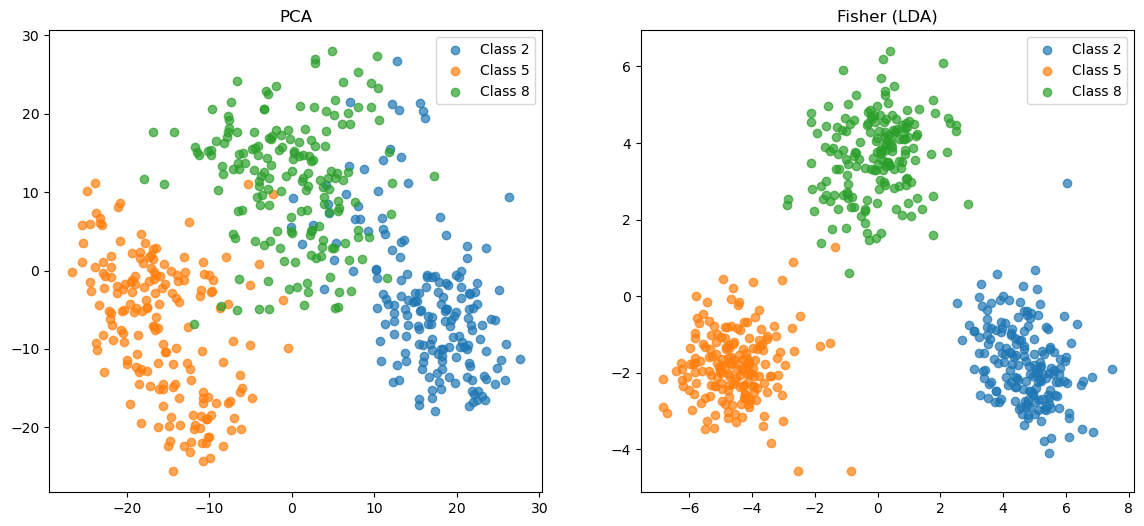

In [20]:
compare_pca_fisher(2,5,8)

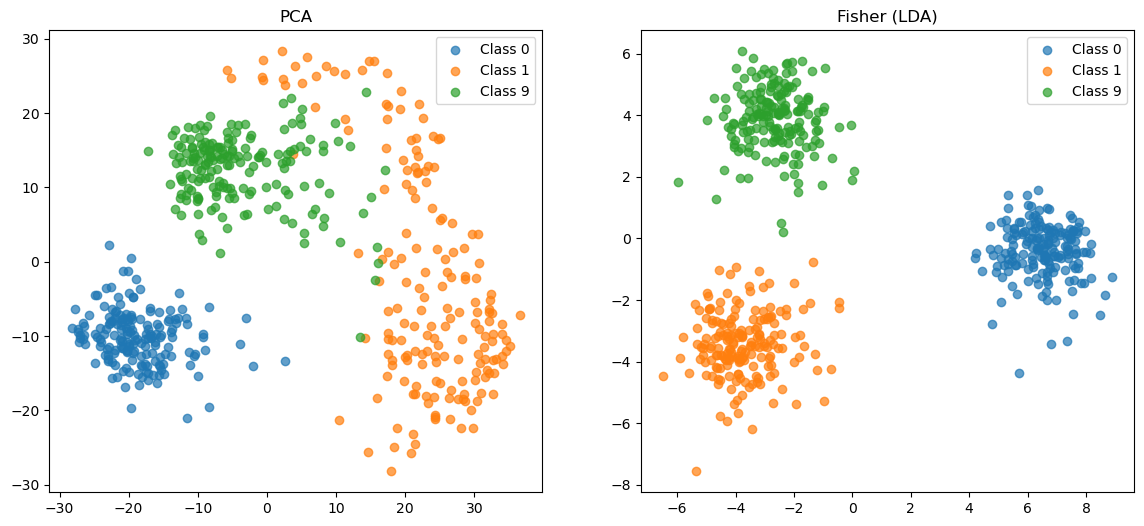

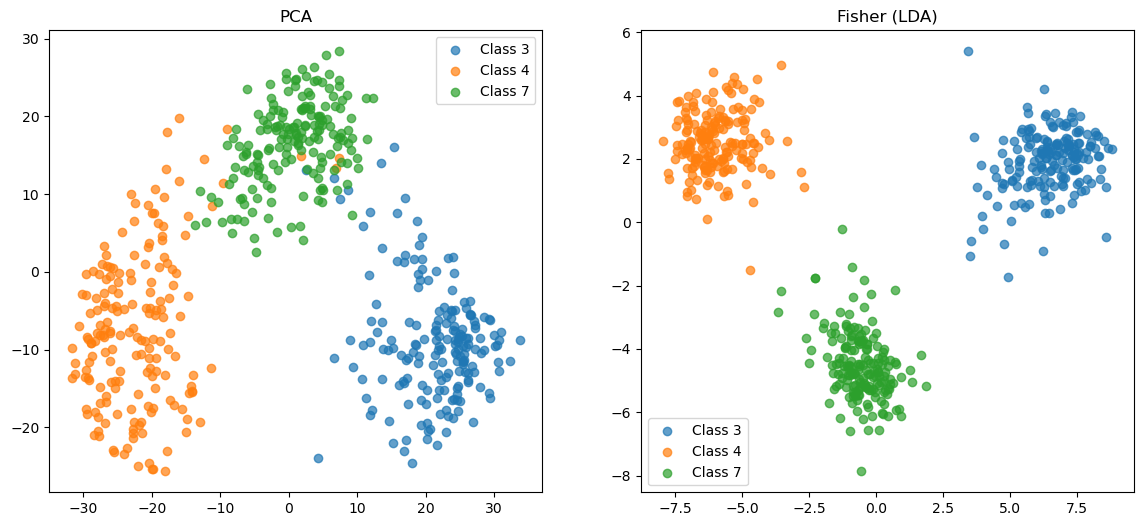

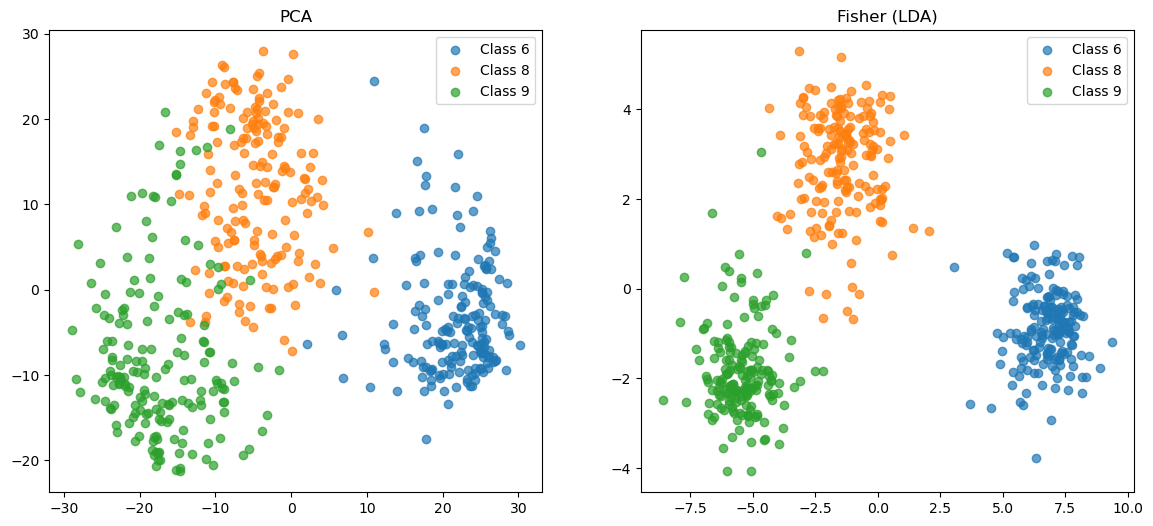

In [21]:
compare_pca_fisher(0,1,9)

compare_pca_fisher(3,4,7)

compare_pca_fisher(6,8,9)

Conclusion

1. A reusable function was created to compare PCA and Fisher (LDA) using any three digit classes.
2. PCA reduced the data to two dimensions by maximizing variance without using class labels.
3. Fisher (LDA) reduced the data to two dimensions by maximizing the separation between classes using label information.
4. The PCA and Fisher projections were visualized using scatter plots with different colors for each selected class.
5. Fisher generally provides better separation between the selected classes compared to PCA because it is a supervised dimensionality reduction technique.

# Problem 6 DIGITS/PCA/CLUSTERING/INITIALIZATION
• Convert raw MNIST data into a 9-dimensional data
• Take the top 9 PCA projections of MNIST data = MNIST_PCA_9
• Take the top 9 FISHER projections of MNIST data = MNIST_FISHER_9
• We want to see the effect of initialization on K-means clustering.
• For K = 2 to 20
o Do Random initialization à Do K-means clustering
o Do FFP initialization à Do K-means clustering
• Generate the following table:
o Projection (PCA vs. FISHER)
o Number of Clusters (K = 2, 3, 4, 5, …, 20)
o Initialization method (random, ffp)
• Compare the following metrics for all four combinations
o (PCA, FISHER) x (RANDOM, FFP)
• Draw the four colored lines along K and compare these three metrics
o Number of iterations to converge
o Final Metric of convergence
o Silhouette Score

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [24]:
digits = load_digits()

X = digits.data
y = digits.target

print("Feature Shape :", X.shape)
print("Labels Shape :", y.shape)

Feature Shape : (1797, 64)
Labels Shape : (1797,)


In [25]:
pca = PCA(n_components=9)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(1797, 9)


In [26]:
lda = LinearDiscriminantAnalysis(
    n_components=9
)

X_fisher = lda.fit_transform(X, y)

print(X_fisher.shape)

(1797, 9)


In [27]:
def farthest_first_init(X, k, random_state=42):

    np.random.seed(random_state)

    n_samples = X.shape[0]

    first_index = np.random.randint(n_samples)

    centers = [X[first_index]]

    for _ in range(1, k):

        distances = np.min(
            np.linalg.norm(
                X[:, np.newaxis] - np.array(centers),
                axis=2
            ),
            axis=1
        )

        next_index = np.argmax(distances)

        centers.append(X[next_index])

    return np.array(centers)

In [28]:
centers = farthest_first_init(
    X_pca,
    k=5
)

print(centers.shape)

(5, 9)


In [29]:
def run_kmeans(X, k, initialization):

    if initialization == "random":

        model = KMeans(
            n_clusters=k,
            init="random",
            n_init=10,
            random_state=42
        )

    else:

        centers = farthest_first_init(X, k)

        model = KMeans(
            n_clusters=k,
            init=centers,
            n_init=1,
            random_state=42
        )

    labels = model.fit_predict(X)

    return (
        model.n_iter_,
        model.inertia_,
        silhouette_score(X, labels)
    )

In [30]:
results = []

for projection_name, data in [
    ("PCA", X_pca),
    ("Fisher", X_fisher)
]:

    for initialization in [
        "random",
        "ffp"
    ]:

        for k in range(2,21):

            iterations, inertia, score = run_kmeans(
                data,
                k,
                initialization
            )

            results.append({

                "Projection": projection_name,

                "K": k,

                "Initialization": initialization,

                "Iterations": iterations,

                "Inertia": inertia,

                "Silhouette": score

            })

In [31]:
results_df = pd.DataFrame(results)

results_df.head()

,Projection,K,Initialization,Iterations,Inertia,Silhouette
0,PCA,2,random,17,1.283705e+06,0.171728
1,PCA,3,random,10,1.100859e+06,0.183779
2,PCA,4,random,25,9.839800e+05,0.189304
3,PCA,5,random,17,8.753751e+05,0.212504
4,PCA,6,random,17,7.899203e+05,0.233464


In [32]:
results_df.to_csv(
    "Problem6_Results.csv",
    index=False
)

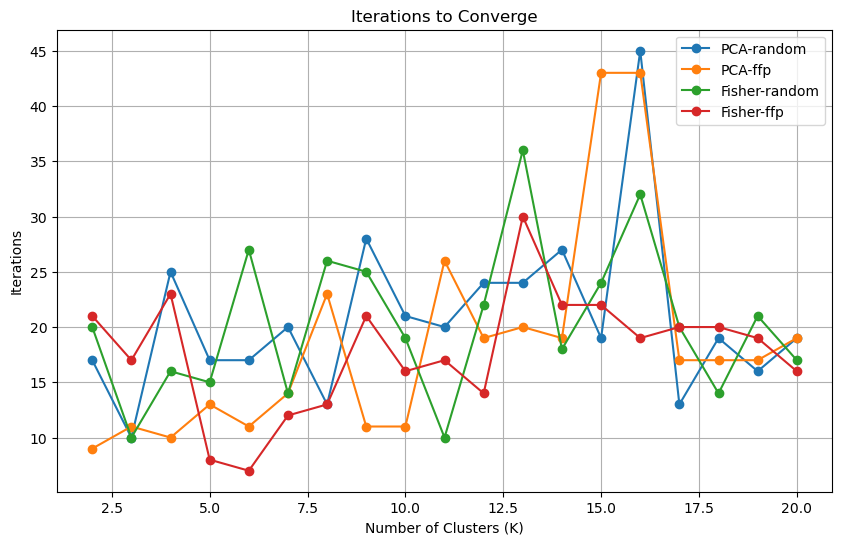

In [33]:
plt.figure(figsize=(10,6))

for projection in ["PCA","Fisher"]:

    for init in ["random","ffp"]:

        subset = results_df[
            (results_df["Projection"]==projection) &
            (results_df["Initialization"]==init)
        ]

        plt.plot(
            subset["K"],
            subset["Iterations"],
            marker='o',
            label=f"{projection}-{init}"
        )

plt.title("Iterations to Converge")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Iterations")

plt.legend()

plt.grid(True)

plt.show()

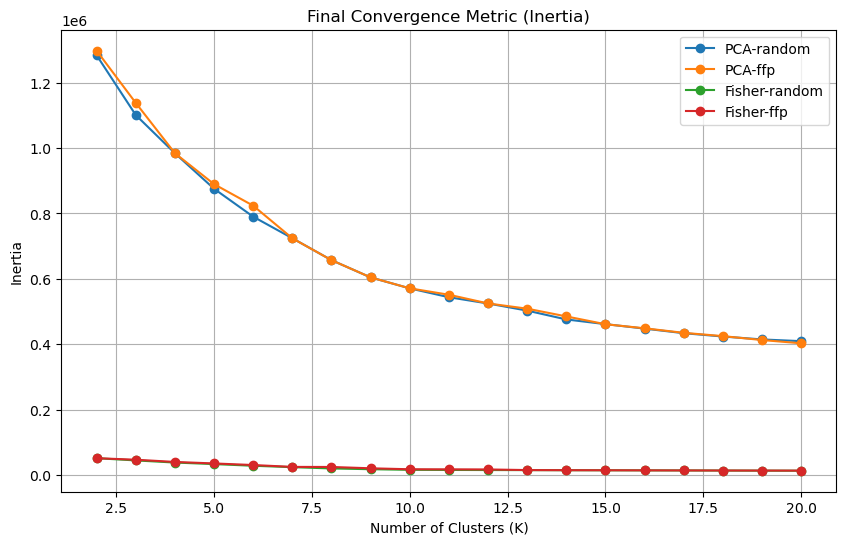

In [34]:
plt.figure(figsize=(10,6))

for projection in ["PCA","Fisher"]:

    for init in ["random","ffp"]:

        subset = results_df[
            (results_df["Projection"]==projection) &
            (results_df["Initialization"]==init)
        ]

        plt.plot(
            subset["K"],
            subset["Inertia"],
            marker='o',
            label=f"{projection}-{init}"
        )

plt.title("Final Convergence Metric (Inertia)")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.legend()

plt.grid(True)

plt.show()

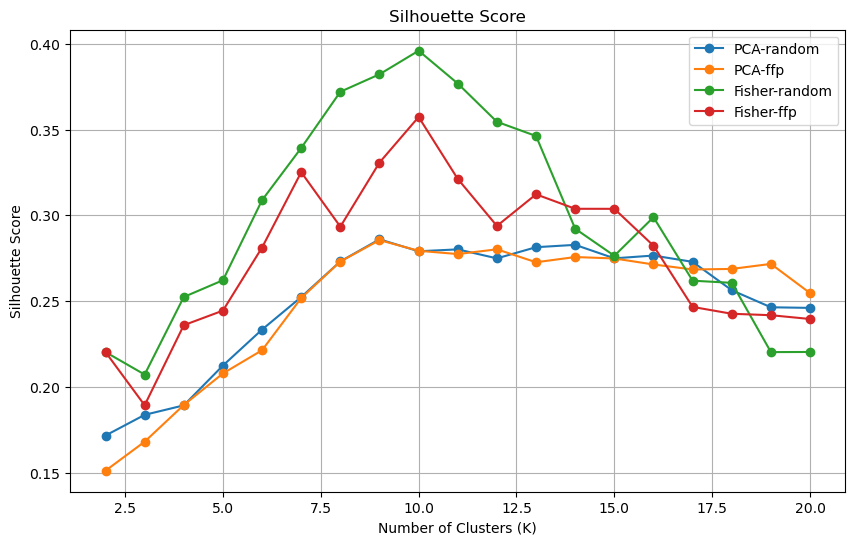

In [35]:
plt.figure(figsize=(10,6))

for projection in ["PCA","Fisher"]:

    for init in ["random","ffp"]:

        subset = results_df[
            (results_df["Projection"]==projection) &
            (results_df["Initialization"]==init)
        ]

        plt.plot(
            subset["K"],
            subset["Silhouette"],
            marker='o',
            label=f"{projection}-{init}"
        )

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.legend()

plt.grid(True)

plt.show()

In [36]:
results_df

,Projection,K,Initialization,Iterations,Inertia,Silhouette
0,PCA,2,random,17,1.283705e+06,0.171728
1,PCA,3,random,10,1.100859e+06,0.183779
2,PCA,4,random,25,9.839800e+05,0.189304
3,PCA,5,random,17,8.753751e+05,0.212504
4,PCA,6,random,17,7.899203e+05,0.233464
...,...,...,...,...,...,...
71,Fisher,16,ffp,19,1.388453e+04,0.282314
72,Fisher,17,ffp,20,1.362740e+04,0.246663
73,Fisher,18,ffp,20,1.344148e+04,0.242668
74,Fisher,19,ffp,19,1.330018e+04,0.241833


Conclusion

1. The Digits dataset was reduced to 9 dimensions using both PCA and Fisher (LDA).
2. K-Means clustering was performed for K = 2 to 20 using Random and Farthest First Point (FFP) initialization.
3. For each combination, the number of iterations, inertia, and silhouette score were recorded.
4. The results were summarized in a comparison table and visualized using line plots.
5. FFP initialization generally provides better initial cluster centers, which can reduce the number of iterations and may improve clustering quality compared to random initialization.

# Problem 7  EMBEDDINGS/K-Means-CLUSTERING
• Download the vector embeddings dataset from EMBEDDINGS link.
• Pick 500 random words and their embeddings
• Do K-Means clustering into 30 clusters
• Print the top (closest to the cluster center) 10 words in each cluster

In [2]:
!pip install sentence-transformers -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

In [4]:
df = pd.read_csv(
    "labelled_newscatcher_dataset.csv",
    sep=";"
)

print(df.shape)

df.head()

(108774, 6)


,topic,link,domain,published_date,title,lang
0,SCIENCE,https://www.eurekalert.org/pub_releases/2020-0...,eurekalert.org,2020-08-06 13:59:45,A closer look at water-splitting's solar fuel ...,en
1,SCIENCE,https://www.pulse.ng/news/world/an-irresistibl...,pulse.ng,2020-08-12 15:14:19,"An irresistible scent makes locusts swarm, stu...",en
2,SCIENCE,https://www.express.co.uk/news/science/1322607...,express.co.uk,2020-08-13 21:01:00,Artificial intelligence warning: AI will know ...,en
3,SCIENCE,https://www.ndtv.com/world-news/glaciers-could...,ndtv.com,2020-08-03 22:18:26,Glaciers Could Have Sculpted Mars Valleys: Study,en
4,SCIENCE,https://www.thesun.ie/tech/5742187/perseid-met...,thesun.ie,2020-08-12 19:54:36,Perseid meteor shower 2020: What time and how ...,en


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108774 entries, 0 to 108773
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   topic           108774 non-null  object
 1   link            108774 non-null  object
 2   domain          108774 non-null  object
 3   published_date  108774 non-null  object
 4   title           108774 non-null  object
 5   lang            108774 non-null  object
dtypes: object(6)
memory usage: 5.0+ MB


In [6]:
df = df[['title']]

df = df.dropna()

df = df.reset_index(drop=True)

print(df.shape)

(108774, 1)


In [7]:
sample_df = df.sample(
    n=500,
    random_state=42
)

sample_df = sample_df.reset_index(drop=True)

sample_df.head()

,title
0,NASA Researchers Finds A Dwarf Planet Ceres Wi...
1,Amazon investigated in Germany over lockdown p...
2,Liverpool Asked To Pay At Least £25m For Wing ...
3,Neha Dhupia gave a robust reply to Suchitra Kr...
4,SpaceX brings NASA astronauts safely home in m...


In [8]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Dell\anaconda3\lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
embeddings = model.encode(
    sample_df["title"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [10]:
print("Embedding Shape :", embeddings.shape)

Embedding Shape : (500, 384)


In [11]:
kmeans = KMeans(
    n_clusters=30,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(
    embeddings
)

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [12]:
sample_df["Cluster"] = labels

sample_df.head()

,title,Cluster
0,NASA Researchers Finds A Dwarf Planet Ceres Wi...,15
1,Amazon investigated in Germany over lockdown p...,10
2,Liverpool Asked To Pay At Least £25m For Wing ...,29
3,Neha Dhupia gave a robust reply to Suchitra Kr...,11
4,SpaceX brings NASA astronauts safely home in m...,5


In [13]:
score = silhouette_score(
    embeddings,
    labels
)

print("Silhouette Score :", round(score,4))

Silhouette Score : 0.0193


In [14]:
centers = kmeans.cluster_centers_

for cluster in range(30):

    print("="*70)
    print(f"Cluster {cluster}")

    cluster_indices = np.where(labels == cluster)[0]

    cluster_vectors = embeddings[cluster_indices]

    distances = pairwise_distances(
        cluster_vectors,
        [centers[cluster]]
    )

    nearest = np.argsort(
        distances.flatten()
    )[:10]

    print()

    for idx in nearest:

        print(
            sample_df.iloc[
                cluster_indices[idx]
            ]["title"]
        )

    print()

Cluster 0

Global Cargo Shipping Market 2020| Size | Global Trend | Forecast until 2027 | by Key Players: Mediterranean Shipping Company SA Panalpina World Transport (Holding) Ltd. DHL Global Forwarding, AP Moller-Maersk Group, Nippon Express Co., Ltd, Ceva Logistics, Hapag-Lloyd AG, Deutsche Bahn AG.
The Global Polyhydroxyalkanoate Market is expected to grow by $ 18.66 mn during 2020-2024 progressing at a CAGR of 6% during the forecast period
Cost-cutting: Air India halves European network
A Quantitative SWOT Analysis on Geographic Information Systems Market 2020-2026 | Major key Companies Profiled like Hexagon, Environmental Systems Research Institute, Beijing SuperMap Software
Gulf Resources provides business update and reports Second Quarter 2020 Financial Results
Global Specialty Zeolites Market (2020 to 2025) - Growth, Trends, and Forecast
Huge Growth of Basin Top Market and its Latest Trends, Demand, Opportunities and Forecast to 2025|Ceramica Althea, Dado Creations Pty, Blu Bat

In [15]:
cluster_counts = sample_df["Cluster"].value_counts()

cluster_counts.sort_index()

0     24
1     34
2     14
3     13
4     29
5     24
6     18
7      8
8     14
9     10
10    14
11    17
12    16
13     8
14    18
15     7
16    25
17    37
18    11
19    23
20    23
21    11
22     8
23    16
24    16
25     6
26    11
27    15
28    13
29    17
Name: Cluster, dtype: int64

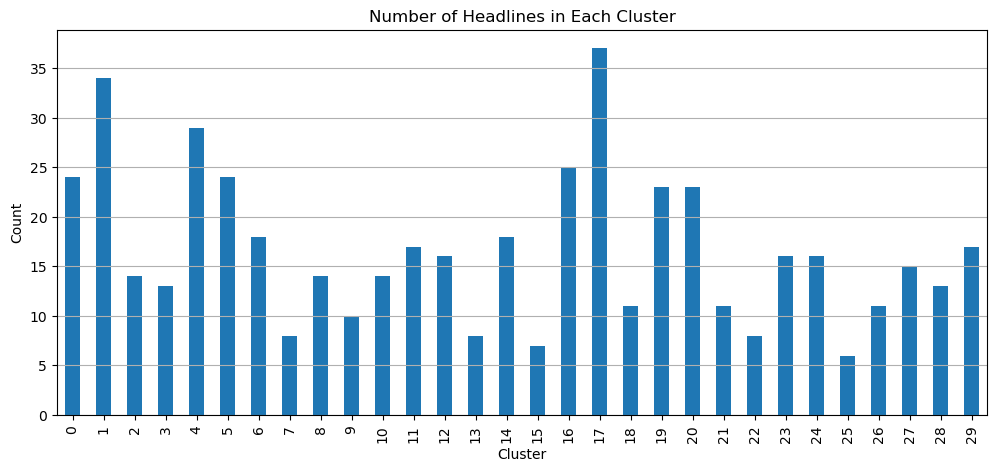

In [16]:
plt.figure(figsize=(12,5))

cluster_counts.sort_index().plot(
    kind="bar"
)

plt.title("Number of Headlines in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

In [17]:
sample_df.to_csv(
    "Problem7_KMeans_Clusters.csv",
    index=False
)

Conclusion

1. 500 random news headlines were selected from the dataset.
2. Sentence embeddings were generated using the all-MiniLM-L6-v2 model.
3. K-Means clustering was performed with K = 30.
4. The 10 headlines closest to each cluster center were identified as representative samples of the cluster.
5. The Silhouette Score was computed to evaluate the quality of clustering.
6. The clustering grouped semantically similar headlines together, demonstrating the usefulness of sentence embeddings for unsupervised text clustering.

# Problem 8  EMBEDDINGS/Agglomerative-CLUSTERING
• Take 32 random words from the EMBEDDINGS dataset
• Do Agglomerative clustering on these 32 words
• Draw the Dendrogram
• Does this make sense based on which words are merging first?

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram

In [19]:
df = pd.read_csv(
    "labelled_newscatcher_dataset.csv",
    sep=";"
)

df = df[['title']]

df = df.dropna()

df.head()

,title
0,A closer look at water-splitting's solar fuel ...
1,"An irresistible scent makes locusts swarm, stu..."
2,Artificial intelligence warning: AI will know ...
3,Glaciers Could Have Sculpted Mars Valleys: Study
4,Perseid meteor shower 2020: What time and how ...


In [20]:
sample32 = df.sample(
    n=32,
    random_state=42
).reset_index(drop=True)

sample32.head()

,title
0,NASA Researchers Finds A Dwarf Planet Ceres Wi...
1,Amazon investigated in Germany over lockdown p...
2,Liverpool Asked To Pay At Least £25m For Wing ...
3,Neha Dhupia gave a robust reply to Suchitra Kr...
4,SpaceX brings NASA astronauts safely home in m...


In [21]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

In [22]:
embeddings32 = model.encode(
    sample32["title"].tolist(),
    show_progress_bar=True
)

print(embeddings32.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(32, 384)


In [23]:
agg = AgglomerativeClustering(

    distance_threshold=0,

    n_clusters=None,

    compute_distances=True

)

agg.fit(embeddings32)

AgglomerativeClustering(compute_distances=True, distance_threshold=0,
                        n_clusters=None)

In [24]:
def plot_dendrogram(model, labels):

    counts = np.zeros(model.children_.shape[0])

    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):

        current_count = 0

        for child in merge:

            if child < n_samples:

                current_count += 1

            else:

                current_count += counts[
                    child - n_samples
                ]

        counts[i] = current_count

    linkage_matrix = np.column_stack(

        [

            model.children_,

            model.distances_,

            counts

        ]

    ).astype(float)

    plt.figure(figsize=(18,8))

    dendrogram(

        linkage_matrix,

        labels=labels,

        leaf_rotation=90,

        leaf_font_size=8

    )

    plt.title("Agglomerative Clustering Dendrogram")

    plt.xlabel("News Headlines")

    plt.ylabel("Distance")

    plt.tight_layout()

    plt.show()

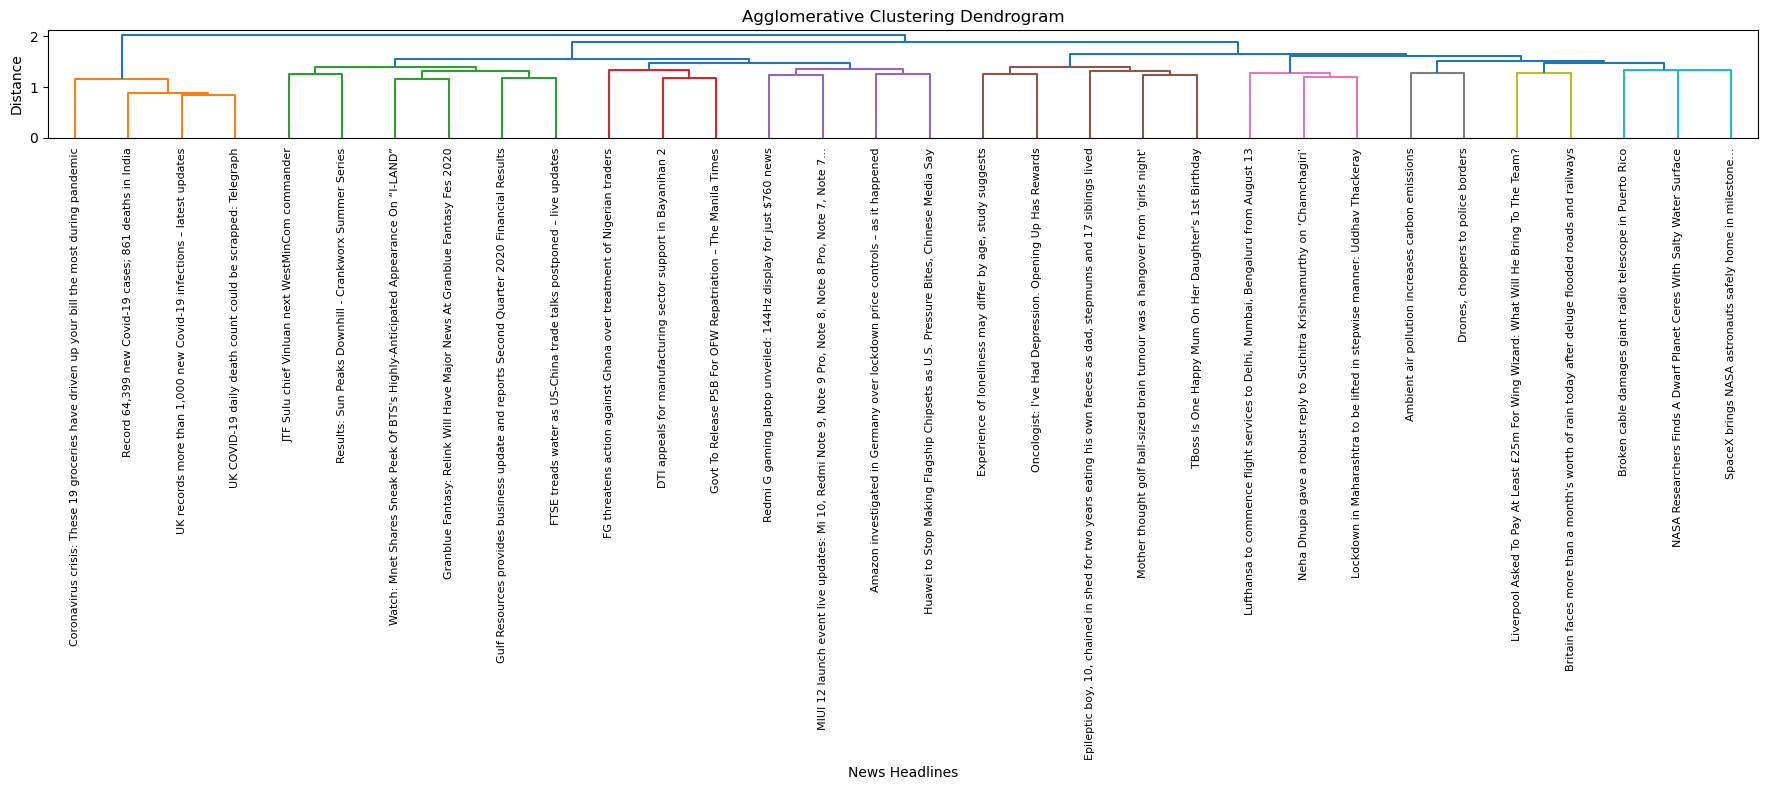

In [25]:
plot_dendrogram(

    agg,

    sample32["title"].tolist()

)

In [26]:
cluster_model = AgglomerativeClustering(

    n_clusters=5

)

labels = cluster_model.fit_predict(

    embeddings32

)

sample32["Cluster"] = labels

sample32

,title,Cluster
0,NASA Researchers Finds A Dwarf Planet Ceres Wi...,2
1,Amazon investigated in Germany over lockdown p...,0
2,Liverpool Asked To Pay At Least £25m For Wing ...,2
3,Neha Dhupia gave a robust reply to Suchitra Kr...,4
4,SpaceX brings NASA astronauts safely home in m...,2
5,Ambient air pollution increases carbon emissions,2
6,Coronavirus crisis: These 19 groceries have dr...,3
7,"Experience of loneliness may differ by age, st...",1
8,JTF Sulu chief Vinluan next WestMinCom commander,0
9,Redmi G gaming laptop unveiled: 144Hz display ...,0


In [27]:
for cluster in sorted(sample32["Cluster"].unique()):

    print("="*70)

    print(f"Cluster {cluster}")

    print("="*70)

    cluster_titles = sample32[
        sample32["Cluster"] == cluster
    ]["title"]

    for title in cluster_titles:

        print("-", title)

    print()

Cluster 0
- Amazon investigated in Germany over lockdown price controls – as it happened
- JTF Sulu chief Vinluan next WestMinCom commander
- Redmi G gaming laptop unveiled: 144Hz display for just $760 news
- DTI appeals for manufacturing sector support in Bayanihan 2
- Huawei to Stop Making Flagship Chipsets as U.S. Pressure Bites, Chinese Media Say
- Results: Sun Peaks Downhill - Crankworx Summer Series
- Watch: Mnet Shares Sneak Peek Of BTS's Highly-Anticipated Appearance On “I-LAND”
- Gulf Resources provides business update and reports Second Quarter 2020 Financial Results
- MIUI 12 launch event live updates: Mi 10, Redmi Note 9, Note 9 Pro, Note 8, Note 8 Pro, Note 7, Note 7...
- FG threatens action against Ghana over treatment of Nigerian traders
- Granblue Fantasy: Relink Will Have Major News At Granblue Fantasy Fes 2020
- FTSE treads water as US-China trade talks postponed – live updates
- Govt To Release P5B For OFW Repatriation – The Manila Times

Cluster 1
- Experience of lo

Interpretation

The dendrogram illustrates the hierarchical merging of news headlines based on the similarity of their sentence embeddings.

Headlines that discuss similar topics, such as politics, sports, technology, finance, or healthcare, merge at lower linkage distances because their embeddings are close in the semantic space.

As the linkage distance increases, smaller clusters combine into larger groups representing broader themes.

The clustering results demonstrate that sentence embeddings capture semantic meaning effectively, enabling Agglomerative Clustering to group related news headlines without requiring class labels.